# Grupo 3 — Random Forest (Poluição)

Primeira aplicação do Random Forest à base tratada do grupo 3. Horizonte: **um horário passo à frente**. Todas as métricas e figuras ficam neste notebook. Os parâmetros abaixo são uma configuração inicial comum, **ainda não otimizados para esta base** (T11 pendente).

In [1]:
from pathlib import Path
import os
import sys
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'preparacao_bases.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from preparacao_bases import carregar_base_tratada
from features_temporais import preparar_features_base
from funcoes_series_temporais import calcular_importancia_features

## T01 — Base tratada e protocolo

O Excel comum fornece o alvo, a frequência, a seed e o instante fixo de início do teste. O modelo não modifica a base tratada.

In [2]:
BASE_NAME = 'poluicao'
GRUPO = 3
UNIDADE = 'PM2.5 (µg/m³)'
df, meta = carregar_base_tratada(BASE_NAME, PROJECT_ROOT)
assert meta['grupo'] == GRUPO and meta['frequencia'] == 'h'
SEED = meta['seed']
INICIO_TESTE = pd.Timestamp(meta['inicio_teste'])
print(f"Base: {BASE_NAME} | alvo: {meta['alvo']} | frequência: {meta['frequencia']}")
print(f"Seed: {SEED} | treino/teste: {meta['treino']:.0%}/{1-meta['treino']:.0%} | início do teste: {INICIO_TESTE}")
print(f"Grade: {len(df):,} períodos | alvo observado: {df[meta['alvo']].notna().sum():,}")

Base: poluicao | alvo: PM2.5 | frequência: h
Seed: 42 | treino/teste: 80%/20% | início do teste: 2016-05-12 19:00:00
Grade: 35,064 períodos | alvo observado: 34,139


## T06 — Features temporais compartilhadas

Lags do alvo e das exógenas, médias móveis e calendário são calculados na grade inteira antes de eliminar linhas com ausências. Todas as medidas do período previsto entram apenas por defasagem.

In [3]:
grade_features = preparar_features_base(
    df, BASE_NAME, meta['alvo'], meta['frequencia'], remover_incompletos=False
)
model_data = grade_features.dropna()
treino = model_data.loc[model_data.index < INICIO_TESTE]
teste = model_data.loc[model_data.index >= INICIO_TESTE]
if treino.empty or teste.empty or treino.index.max() >= teste.index.min():
    raise ValueError('Treino/teste temporal inválido ou sem linhas completas.')
X_train, y_train = treino.drop(columns='target'), treino['target']
X_test, y_test = teste.drop(columns='target'), teste['target']
observados_teste = int(df.loc[df.index >= INICIO_TESTE, meta['alvo']].notna().sum())
cobertura = pd.DataFrame([{
    'features': X_train.shape[1], 'treino_elegivel': len(treino),
    'teste_grade': meta['linhas_teste'], 'teste_alvo_observado': observados_teste,
    'teste_elegivel': len(teste),
    'cobertura_grade_%': 100 * len(teste) / meta['linhas_teste'],
    'cobertura_alvos_observados_%': 100 * len(teste) / observados_teste,
}])
display(cobertura.round(2))
print('Todas as linhas avaliadas têm alvo e features observados; períodos excluídos não entram no MAE.')

# Diagnóstico de mudança de faixa do alvo; usado só para interpretar o teste.
alvo_treino = df.loc[df.index < INICIO_TESTE, meta['alvo']].dropna()
alvo_teste = df.loc[df.index >= INICIO_TESTE, meta['alvo']].dropna()
faixa_alvo = pd.DataFrame([{
    'min_treino': alvo_treino.min(), 'max_treino': alvo_treino.max(),
    'min_teste': alvo_teste.min(), 'max_teste': alvo_teste.max(),
    'teste_acima_max_treino_%': 100 * alvo_teste.gt(alvo_treino.max()).mean(),
}])
display(faixa_alvo.round(2))


,features,treino_elegivel,teste_grade,teste_alvo_observado,teste_elegivel,cobertura_grade_%,cobertura_alvos_observados_%
0,40,11752,7013,6906,3023,43.11,43.77


Todas as linhas avaliadas têm alvo e features observados; períodos excluídos não entram no MAE.


,min_treino,max_treino,min_teste,max_teste,teste_acima_max_treino_%
0,3.0,898.0,3.0,713.0,0.0


## T11 — Busca temporal do Random Forest

Doze configurações são comparadas em três blocos expansivos, somente dentro do treino. O melhor modelo e seus parâmetros são congelados antes do teste. A linha da persistência é referência, não um candidato RF.

,fold,treino_ate,validacao_inicio,validacao_fim,n_treino,n_validacao
0,1,2014-09-28 15:00:00,2014-11-14 20:00:00,2015-05-12 15:00:00,8262,1031
1,2,2015-05-12 15:00:00,2015-05-26 17:00:00,2015-11-01 02:00:00,9293,1270
2,3,2015-11-01 02:00:00,2015-11-17 13:00:00,2016-05-07 19:00:00,10563,1189


nivel 1/12: MAE=10.8498


nivel 2/12: MAE=9.3182


nivel 3/12: MAE=10.9312


nivel 4/12: MAE=9.3101


...

nivel 10/12: MAE=10.8598


nivel 11/12: MAE=10.9001


nivel 12/12: MAE=11.0072


,estrategia,indice,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,MAE_validacao,desvio_MAE_folds,RMSE_validacao
0,nivel,7,200,5,2,1.0,10.0,9.1704,2.0499,19.7933
1,nivel,3,200,5,2,1.0,NaN,9.3101,2.0556,19.8842
2,nivel,1,100,2,2,1.0,NaN,9.3182,2.0515,19.8890
3,nivel,6,100,2,1,1.0,10.0,9.4211,1.8292,19.9464
4,nivel,5,200,2,1,1.0,NaN,9.6041,1.8146,19.9421
5,nivel,8,100,2,2,sqrt,10.0,10.8471,2.5100,24.1345
6,nivel,0,200,5,1,sqrt,NaN,10.8498,2.6967,24.0553
7,nivel,9,200,2,1,sqrt,NaN,10.8598,2.5667,23.7106
8,nivel,10,100,2,5,sqrt,10.0,10.9001,2.6109,24.8127
9,nivel,2,100,5,1,sqrt,NaN,10.9312,2.7955,24.0110


Persistência na validação: MAE=8.9699
Melhor RF: nivel, MAE=9.1704; parâmetros={'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 10}
Tempo da busca: 2.6 min


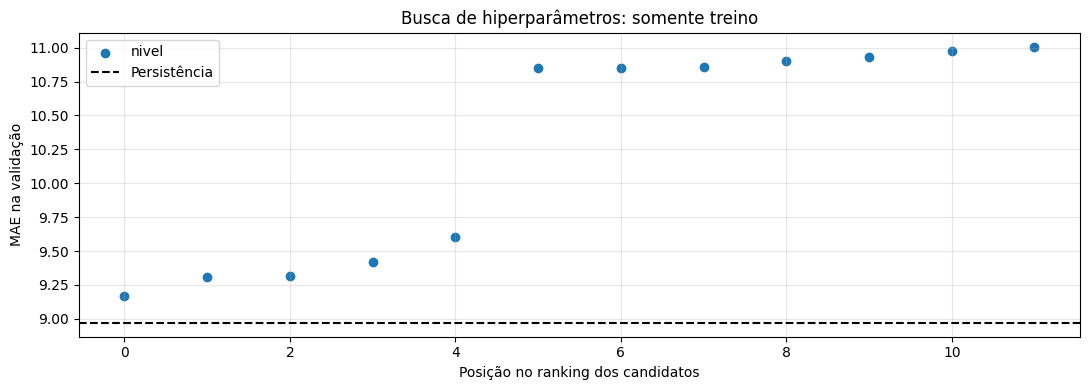

In [4]:
# T11 — busca apenas nas janelas de desenvolvimento do treino.
from sklearn.model_selection import ParameterSampler
from sklearn.base import BaseEstimator, RegressorMixin
from walk_forward import validar_previsoes

MESES_VALIDACAO = 6
N_SPLITS_VALIDACAO = 3
N_CANDIDATOS = 12
N_JOBS = min(4, os.cpu_count() or 1)
ESTRATEGIAS = ('nivel',)
PARAM_GRID = {
    'n_estimators': [100, 200], 'max_depth': [10, None],
    'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 1.0],
}

class FlorestaIncremento(RegressorMixin, BaseEstimator):
    """Prevê a variação sobre t-1; devolve a previsão na escala original."""
    def __init__(self, parametros, seed, n_jobs):
        self.parametros = parametros
        self.seed = seed
        self.n_jobs = n_jobs
    def fit(self, X, y):
        self.floresta_ = RandomForestRegressor(**self.parametros, random_state=self.seed, n_jobs=self.n_jobs)
        self.floresta_.fit(X, np.asarray(y) - X['target_lag_1'].to_numpy())
        self.n_features_in_ = X.shape[1]
        return self
    def predict(self, X):
        return X['target_lag_1'].to_numpy() + self.floresta_.predict(X)

def criar_modelo(parametros, estrategia):
    if estrategia == 'incremento':
        return FlorestaIncremento(parametros, SEED, N_JOBS)
    return RandomForestRegressor(**parametros, random_state=SEED, n_jobs=N_JOBS)

folds, linhas_folds = [], []
for i in range(N_SPLITS_VALIDACAO):
    inicio_val = INICIO_TESTE - pd.DateOffset(months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i))
    fim_val = INICIO_TESTE - pd.DateOffset(months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i - 1))
    ia = np.flatnonzero(X_train.index < inicio_val)
    iv = np.flatnonzero((X_train.index >= inicio_val) & (X_train.index < fim_val))
    if not len(ia) or not len(iv) or X_train.index[ia].max() >= X_train.index[iv].min():
        raise ValueError('Fold de validação vazio ou fora da ordem temporal.')
    folds.append((ia, iv))
    linhas_folds.append({'fold': i+1, 'treino_ate': X_train.index[ia].max(),
        'validacao_inicio': X_train.index[iv].min(), 'validacao_fim': X_train.index[iv].max(),
        'n_treino': len(ia), 'n_validacao': len(iv)})
display(pd.DataFrame(linhas_folds))

PARAMETROS = list(ParameterSampler(PARAM_GRID, n_iter=N_CANDIDATOS, random_state=SEED))
mae_persistencia_validacao = np.mean(np.concatenate([
    np.abs(y_train.iloc[iv].to_numpy() - X_train.iloc[iv]['target_lag_1'].to_numpy())
    for _, iv in folds
]))
resultados_grid = []
inicio_grid = time.perf_counter()
for estrategia in ESTRATEGIAS:
    for indice, params in enumerate(PARAMETROS):
        erros, maes_fold = [], []
        for ia, iv in folds:
            candidato = criar_modelo(params, estrategia)
            candidato.fit(X_train.iloc[ia], y_train.iloc[ia])
            erro = y_train.iloc[iv].to_numpy() - candidato.predict(X_train.iloc[iv])
            erros.append(erro)
            maes_fold.append(float(np.abs(erro).mean()))
        erros = np.concatenate(erros)
        resultados_grid.append({'estrategia': estrategia, 'indice': indice, **params,
            'MAE_validacao': float(np.abs(erros).mean()),
            'desvio_MAE_folds': float(np.std(maes_fold, ddof=1)),
            'RMSE_validacao': float(np.sqrt(np.mean(erros**2)))})
        print(f"{estrategia} {indice+1}/{len(PARAMETROS)}: MAE={resultados_grid[-1]['MAE_validacao']:.4f}")

df_grid = pd.DataFrame(resultados_grid).sort_values('MAE_validacao').reset_index(drop=True)
BEST_ESTRATEGIA = str(df_grid.loc[0, 'estrategia'])
BEST_PARAMS = PARAMETROS[int(df_grid.loc[0, 'indice'])].copy()
display(df_grid.round(4))
print(f'Persistência na validação: MAE={mae_persistencia_validacao:.4f}')
print(f'Melhor RF: {BEST_ESTRATEGIA}, MAE={df_grid.loc[0, "MAE_validacao"]:.4f}; parâmetros={BEST_PARAMS}')
print(f'Tempo da busca: {(time.perf_counter()-inicio_grid)/60:.1f} min')

fig, ax = plt.subplots(figsize=(11, 4))
for nome, parte in df_grid.groupby('estrategia'):
    ax.scatter(parte.index, parte['MAE_validacao'], label=nome)
ax.axhline(mae_persistencia_validacao, color='black', linestyle='--', label='Persistência')
ax.set(xlabel='Posição no ranking dos candidatos', ylabel='MAE na validação',
       title='Busca de hiperparâmetros: somente treino')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## T12 — RF com parâmetros escolhidos na validação

Ajuste único no treino completo. No teste, os lags são atualizados quando as observações anteriores já estão disponíveis. O protocolo comum confere se todas as datas elegíveis receberam exatamente uma previsão.

In [5]:
modelo = criar_modelo(BEST_PARAMS, BEST_ESTRATEGIA)
inicio = time.perf_counter()
modelo.fit(X_train, y_train)
previsto = modelo.predict(X_test)
tempo_ajuste = time.perf_counter() - inicio
previsoes = pd.DataFrame({
    'real': y_test.to_numpy(), 'random_forest': previsto,
    'persistencia': X_test['target_lag_1'].to_numpy(),
}, index=X_test.index)
previsoes.index.name = 'data'
previsoes['residuo'] = previsoes['real'] - previsoes['random_forest']
print(f"Ajuste e previsão: {tempo_ajuste:.1f} s | previsões: {len(previsoes):,}")
conferencia_t08 = validar_previsoes(BASE_NAME, previsoes.index, PROJECT_ROOT)
assert conferencia_t08['ok'], conferencia_t08
print('T08 — origens de teste:', conferencia_t08)


Ajuste e previsão: 9.0 s | previsões: 3,023


T08 — origens de teste: {'base': 'poluicao', 'origens_oficiais': 3023, 'previsoes': 3023, 'duplicadas': 0, 'ordenadas': True, 'faltando': 0, 'fora_do_protocolo': 0, 'ok': True}


## T16 — Métricas preliminares

RF e persistência são comparados nos **mesmos timestamps elegíveis**. O teste completo só será comparável aos demais modelos se eles adotarem essa mesma avaliação. O ranking dos 20 pipelines permanece pendente.

In [6]:
def resumir(nome, real, predito):
    erro = real - predito
    return {
        'modelo': nome, 'n': len(real),
        'MAE': mean_absolute_error(real, predito),
        'RMSE': np.sqrt(mean_squared_error(real, predito)),
        'R2': r2_score(real, predito),
        'desvio_residual': np.std(erro, ddof=1),
        'vies_real_menos_previsto': np.mean(erro),
    }
metricas = pd.DataFrame([
    resumir('Random Forest', previsoes['real'], previsoes['random_forest']),
    resumir('Persistência', previsoes['real'], previsoes['persistencia']),
])
mae_rf = float(metricas.loc[metricas.modelo == 'Random Forest', 'MAE'].iloc[0])
mae_persistencia = float(metricas.loc[metricas.modelo == 'Persistência', 'MAE'].iloc[0])
metricas['ganho_MAE_vs_persistencia_%'] = 100 * (1 - metricas['MAE'] / mae_persistencia)
display(metricas.round(4))
print(f'MAE RF: {mae_rf:.4f} | MAE persistência: {mae_persistencia:.4f} | unidade: {UNIDADE}')
if mae_rf >= mae_persistencia:
    print('Com parâmetros escolhidos na validação, o RF não superou a persistência. A próxima mudança deve ser escolhida na validação do treino.')
else:
    print('Com parâmetros escolhidos na validação, o RF superou a persistência nos períodos elegíveis.')


,modelo,n,MAE,RMSE,R2,desvio_residual,vies_real_menos_previsto,ganho_MAE_vs_persistencia_%
0,Random Forest,3023,10.2024,17.8922,0.9574,17.8815,0.7004,-1.0741
1,Persistência,3023,10.0939,18.2167,0.9558,18.2194,-0.1085,0.0000


MAE RF: 10.2024 | MAE persistência: 10.0939 | unidade: PM2.5 (µg/m³)
Com parâmetros escolhidos na validação, o RF não superou a persistência. A próxima mudança deve ser escolhida na validação do treino.


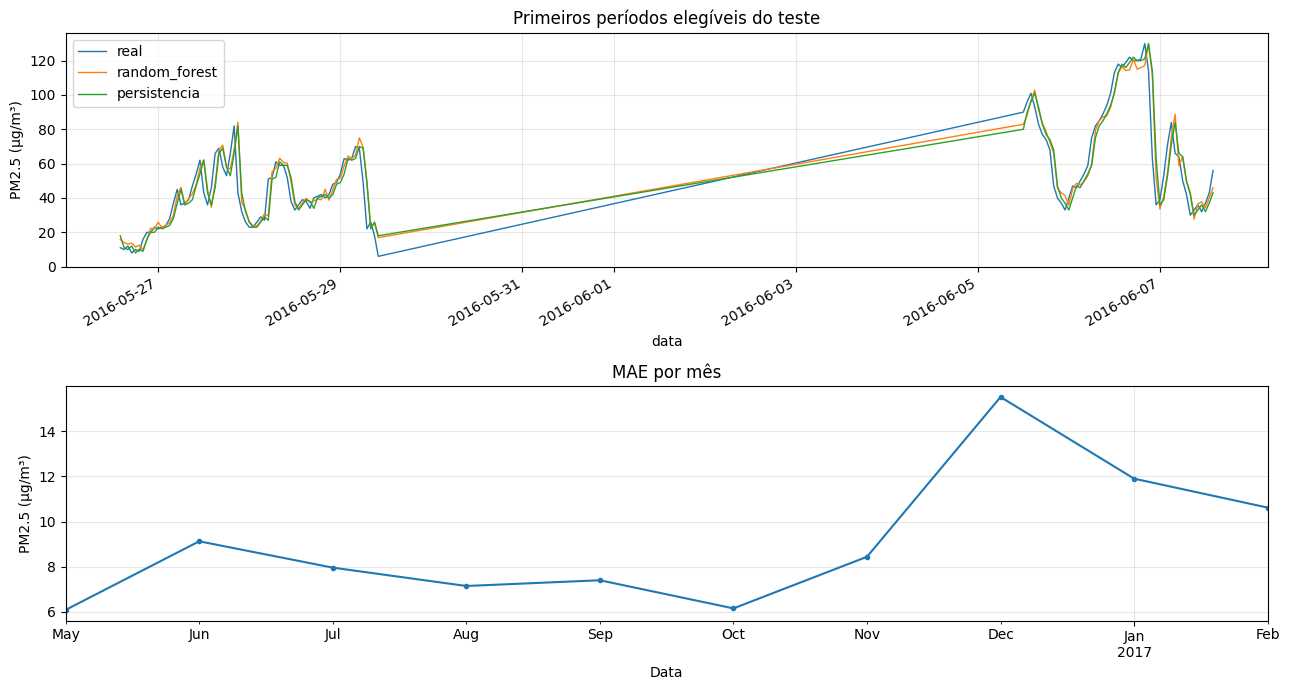

O MAE global acima usa todos os períodos elegíveis, não apenas os mostrados no gráfico superior.


In [7]:
janela = previsoes.iloc[:min(120, len(previsoes))]
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
janela[['real', 'random_forest', 'persistencia']].plot(ax=axes[0], linewidth=1)
axes[0].set(title='Primeiros períodos elegíveis do teste', ylabel=UNIDADE)
periodo_mae = 'MS' if meta['frequencia'] in ('D', 'h') else 'YS'
mae_periodo = previsoes['residuo'].abs().resample(periodo_mae).agg(['mean', 'count'])
mae_periodo.columns = ['MAE', 'n']
mae_periodo.loc[mae_periodo['n'] > 0, 'MAE'].plot(ax=axes[1], marker='o', markersize=3)
axes[1].set(title='MAE por mês' if periodo_mae == 'MS' else 'MAE por ano', ylabel=UNIDADE, xlabel='Data')
for ax in axes: ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print('O MAE global acima usa todos os períodos elegíveis, não apenas os mostrados no gráfico superior.')

## T17 — Diagnóstico dos resíduos

A série de erros usa todos os períodos elegíveis do teste. A ACF e o Ljung-Box usam o maior trecho sem lacunas na frequência original, pois saltar períodos mudaria o significado dos lags.

Resíduos: média=0.7004, desvio-padrão=17.8815; ACF no maior trecho contínuo: 626 períodos.


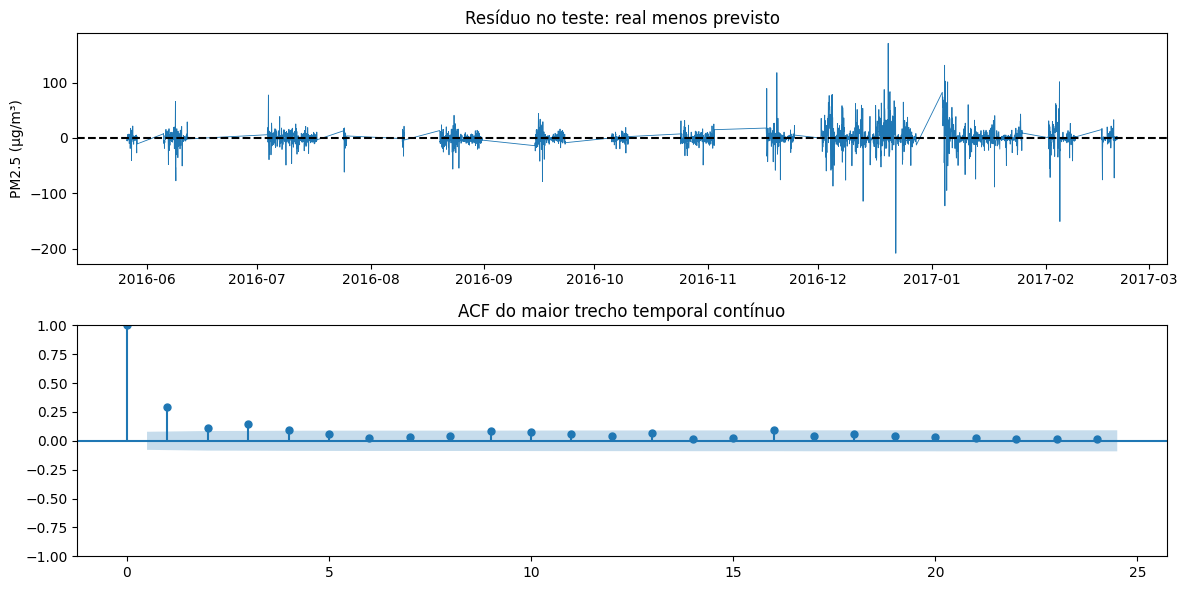

,lb_stat,lb_pvalue
1,55.197563,1.090038e-13
6,82.945377,8.791653e-16
12,97.192962,1.971178e-15
24,112.480615,2.074078e-13


p < 0,05 indica autocorrelação residual; não prova, por si só, inutilidade preditiva.


In [8]:
# T17 — resíduos fora da amostra, sem comprimir lacunas temporais.
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

residuos = previsoes['residuo'].sort_index()
passo = pd.Timedelta(hours=1)
blocos = residuos.index.to_series().diff().ne(passo).cumsum()
trecho = max((parte for _, parte in residuos.groupby(blocos.to_numpy())), key=len)
print(f'Resíduos: média={residuos.mean():.4f}, desvio-padrão={residuos.std():.4f}; '
      f'ACF no maior trecho contínuo: {len(trecho):,} períodos.')
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(residuos.index, residuos.to_numpy(), linewidth=.6)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set(title='Resíduo no teste: real menos previsto', ylabel=UNIDADE)
max_lag = min(24, max(1, len(trecho)//5))
plot_acf(trecho, lags=max_lag, ax=axes[1], title='ACF do maior trecho temporal contínuo')
plt.tight_layout(); plt.show()
lags_lb = [lag for lag in [1, 6, 12, 24] if lag <= max_lag]
display(acorr_ljungbox(trecho, lags=lags_lb, return_df=True))
print('p < 0,05 indica autocorrelação residual; não prova, por si só, inutilidade preditiva.')

## T18 — Importância preliminar das features

Permutação no teste, com amostra fixa de até 500 períodos. O desvio representa a variação entre três permutações. Esta análise é interpretativa; a seleção de atributos ainda deve ocorrer somente na validação do treino.

,feature,importancia,desvio_importancia
0,target_lag_1,77.4845,2.6232
1,target_lag_2,3.1374,0.3758
2,PM10_lag_1,1.5651,0.1624
3,NO2_lag_1,1.0126,0.0433
4,target_roll_mean_6,0.8038,0.2705
5,WSPM_lag_1,0.5206,0.1851
6,NO2_lag_24,0.3814,0.0791
7,target_roll_std_168,0.1163,0.0768
8,TEMP_lag_1,0.1051,0.0793
9,target_roll_std_24,0.0680,0.0341


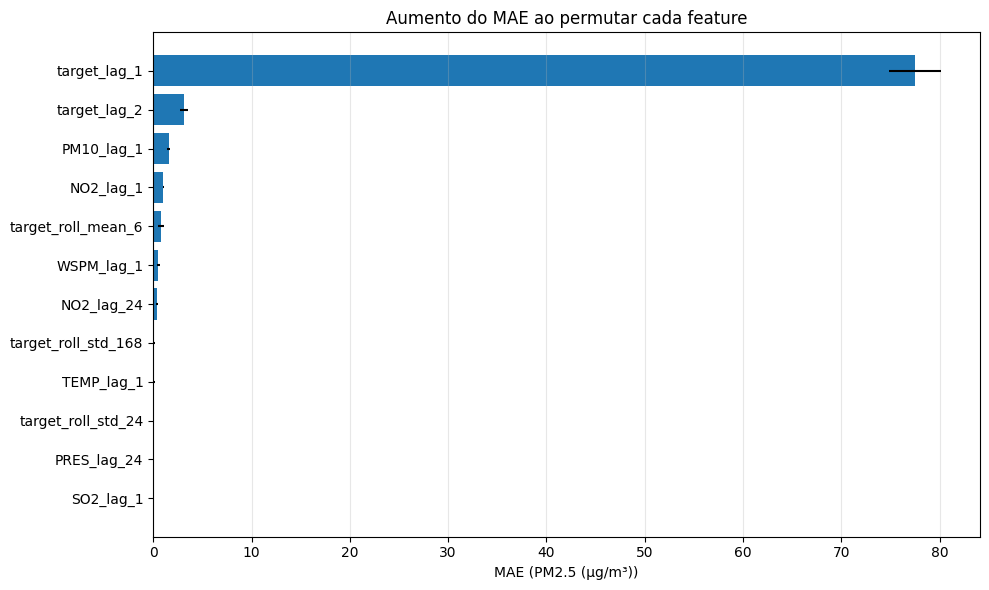

In [9]:
importancias = calcular_importancia_features(
    modelo, X_test, y_test, metodo='permutacao',
    n_repeticoes=3, seed=SEED, n_jobs=1, max_amostras=500,
)
display(importancias[['feature', 'importancia', 'desvio_importancia']].head(12).round(4))
top = importancias.head(12).sort_values('importancia')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top['feature'], top['importancia'], xerr=top['desvio_importancia'])
ax.set(title='Aumento do MAE ao permutar cada feature', xlabel=f'MAE ({UNIDADE})')
ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()

### Limites e próximos passos

A configuração foi escolhida em validação temporal e as previsões cobrem as origens elegíveis do protocolo T08. A comparação final dos 20 pipelines depende das execuções dos demais modelos nas mesmas datas. A estratégia de reajuste periódico continua específica de cada família de modelo e deve ser declarada no relatório.